In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("WELFake_Dataset.csv")

In [3]:
df.head()

,index,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   index   72134 non-null  int64 
 1   title   71576 non-null  object
 2   text    72095 non-null  object
 3   label   72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


,index,label
count,72134.000000,72134.000000
mean,36066.500000,0.514404
std,20823.436496,0.499796
min,0.000000,0.000000
25%,18033.250000,0.000000
50%,36066.500000,1.000000
75%,54099.750000,1.000000
max,72133.000000,1.000000


In [5]:
df = df.drop(columns=["index"])

In [6]:
df.isnull().sum()

title    558
text      39
label      0
dtype: int64

In [7]:
df = df.dropna(subset=["title", "text"])

In [8]:
df = df.drop_duplicates()

In [9]:
df["full_text"] = df["title"] + " " + df["text"]
df["text_length"] = df["full_text"].apply(len)
df["exclamation_count"] = df["full_text"].apply(lambda x: x.count("!"))

def uppercase_ratio(text):
    if len(text) == 0:
        return 0
    return sum(1 for c in text if c.isupper()) / len(text)

df["uppercase_ratio"] = df["full_text"].apply(uppercase_ratio)

In [10]:
df["label"].value_counts()

label
0    34791
1    28330
Name: count, dtype: int64

In [11]:
df = df.reset_index(drop=True)

In [12]:
df["label"] = 1 - df["label"]

In [13]:
df[["text_length", "exclamation_count", "uppercase_ratio"]].describe()

,text_length,exclamation_count,uppercase_ratio
count,63121.000000,63121.000000,63121.000000
mean,3379.177453,0.487223,0.049416
std,3640.677004,2.160225,0.047130
min,14.000000,0.000000,0.000000
25%,1538.000000,0.000000,0.031592
50%,2545.000000,0.000000,0.039216
75%,4193.000000,0.000000,0.051282
max,143035.000000,213.000000,0.852941


In [14]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["clean_text"] = df["full_text"].apply(clean_text)

In [15]:
df.head()

,title,text,label,full_text,text_length,exclamation_count,uppercase_ratio,clean_text
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,5180,2,0.039961,law enforcement on high alert following threat...
1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",0,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,354,1,0.271186,unbelievable obamas attorney general says most...
2,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,1,"Bobby Jindal, raised Hindu, uses story of Chri...",8116,0,0.030803,bobby jindal raised hindu uses story of christ...
3,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",0,SATAN 2: Russia unvelis an image of its terrif...,2012,0,0.069085,satan russia unvelis an image of its terrifyi...
4,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,0,About Time! Christian Group Sues Amazon and SP...,1609,2,0.068365,about time christian group sues amazon and spl...


In [16]:
import matplotlib.pyplot as plt
import pandas as pd

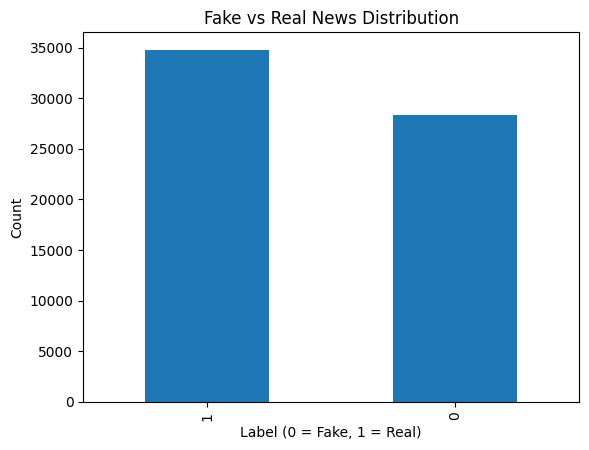

In [17]:
df["label"].value_counts().plot(kind="bar")
plt.title("Fake vs Real News Distribution")
plt.xlabel("Label (0 = Fake, 1 = Real)")
plt.ylabel("Count")
plt.show()

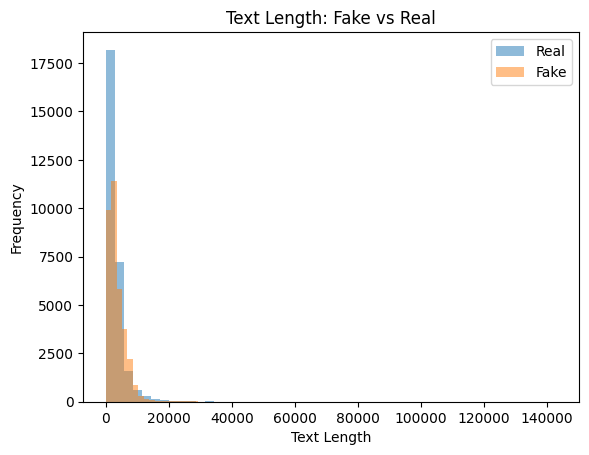

In [18]:
plt.hist(df[df["label"] == 0]["text_length"], bins=50, alpha=0.5, label="Real")
plt.hist(df[df["label"] == 1]["text_length"], bins=50, alpha=0.5, label="Fake")
plt.legend()
plt.title("Text Length: Fake vs Real")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

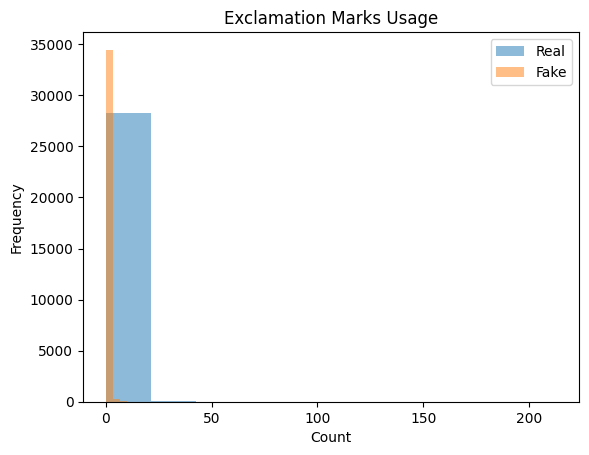

In [19]:
plt.hist(df[df["label"] == 0]["exclamation_count"], alpha=0.5, label="Real")
plt.hist(df[df["label"] == 1]["exclamation_count"], alpha=0.5, label="Fake")
plt.legend()
plt.title("Exclamation Marks Usage")
plt.xlabel("Count")
plt.ylabel("Frequency")
plt.show()

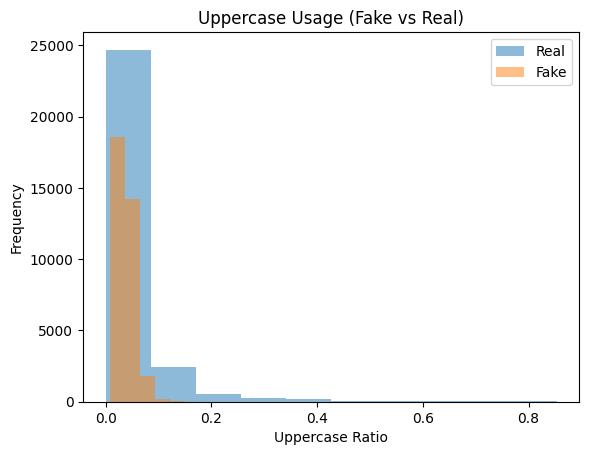

In [20]:
plt.hist(df[df["label"] == 0]["uppercase_ratio"], alpha=0.5, label="Real")
plt.hist(df[df["label"] == 1]["uppercase_ratio"], alpha=0.5, label="Fake")
plt.legend()
plt.title("Uppercase Usage (Fake vs Real)")
plt.xlabel("Uppercase Ratio")
plt.ylabel("Frequency")
plt.show()

In [21]:
from collections import Counter

fake_words = " ".join(df[df["label"] == 1]["clean_text"]).split()
real_words = " ".join(df[df["label"] == 0]["clean_text"]).split()

fake_common = Counter(fake_words).most_common(10)
real_common = Counter(real_words).most_common(10)

print("Fake news common words:", fake_common)
print("Real news common words:", real_common)

Fake news common words: [('the', 1188297), ('to', 580372), ('of', 516511), ('a', 501314), ('and', 463985), ('in', 434202), ('that', 250734), ('on', 219433), ('for', 196773), ('said', 183338)]
Real news common words: [('the', 791778), ('to', 415593), ('of', 365096), ('and', 343103), ('a', 297510), ('in', 251040), ('that', 209096), ('is', 174120), ('for', 134433), ('on', 114536)]


# Training

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import scipy.sparse as sp

In [23]:
X_text = df["clean_text"]
X_tabular = df[["text_length", "exclamation_count", "uppercase_ratio"]]
y = df["label"]

X_text_train, X_text_test, X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_text, X_tabular, y, test_size=0.2, random_state=42
)

In [24]:
tfidf = TfidfVectorizer(max_features=2000, stop_words='english')

X_text_train_tfidf = tfidf.fit_transform(X_text_train)
X_text_test_tfidf = tfidf.transform(X_text_test)

In [25]:
X_train = sp.hstack((X_text_train_tfidf, X_tab_train))
X_test = sp.hstack((X_text_test_tfidf, X_tab_test))

In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

In [27]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9473267326732673
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      5670
           1       0.96      0.95      0.95      6955

    accuracy                           0.95     12625
   macro avg       0.95      0.95      0.95     12625
weighted avg       0.95      0.95      0.95     12625



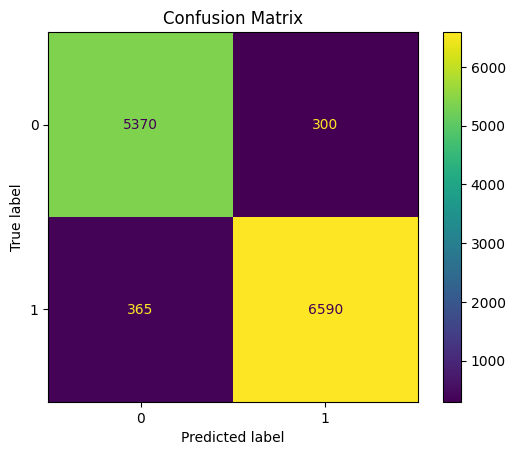

In [28]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

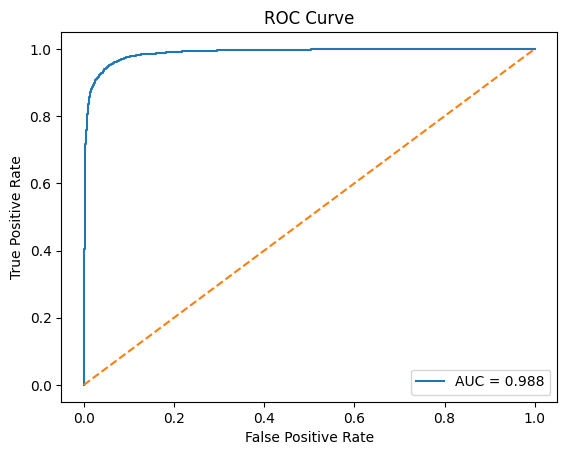

In [29]:
y_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [30]:
import pickle

# save model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# save tfidf
with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)